# M4 — Computación Paralela y Análisis de Rendimiento
## Sistema de Recomendación Paralelo para E-Commerce — RetailRocket Dataset
### Entrega 2 — Implementación Inicial y Validación Parcial

Este notebook mide speedup y eficiencia de las tres etapas del pipeline
(ETL de M1, clustering de M2, entrenamiento de M3), perfila el
entrenamiento para identificar cuellos de botella, y documenta el
protocolo de medición usado (warm-up + repeticiones).

| Criterio | Sección |
|---|---|
| Avance funcional | 2, 3, 4 (speedup ETL, clustering, entrenamiento) |
| Organización del código | Módulo `src/benchmarks.py`, funciones parametrizables |
| Validación inicial | 6 (tabla resumen de speedup por etapa) + 5 (profiling) |
| Gestión de problemas | 1 (protocolo) y 7 (cuellos de botella) |

**Herramientas:** cProfile, threadpoolctl, Dask, pandas.


## 0. Configuración inicial

In [2]:
# !pip install dask[distributed] scikit-learn implicit threadpoolctl pandas polars


In [4]:
RAIZ_PROYECTO = Path(r"E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Codigos")
sys.path.append(str(RAIZ_PROYECTO / "src"))

from pipeline_datos import cargar_eventos_procesados                          # Módulo M1
from analisis_eda import construir_features_usuario, cargar_segmentos          # Módulo M2
from modelo_recomendacion import construir_matriz_interacciones, dividir_train_test  # Módulo M3
from benchmarks import (                                                       # Módulo M4
    medir_tiempo_repetido,
    benchmark_etl_workers,
    benchmark_clustering_threads,
    benchmark_entrenamiento_als_threads,
    perfilar_funcion,
    guardar_resultados,
)

CARPETA_PROCESSED = RAIZ_PROYECTO / "datos"
CARPETA_RESULTADOS = RAIZ_PROYECTO / "resultados"
CARPETA_DATASETS = RAIZ_PROYECTO.parent / "Datasets"
CARPETA_RESULTADOS.mkdir(exist_ok=True)

print("Módulos de M1, M2 y M3 importados correctamente.")


C:\Users\mora7\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Módulos de M1, M2 y M3 importados correctamente.


## 1. Protocolo de medición (Gestión de problemas)

Todas las mediciones de este notebook siguen el mismo protocolo, implementado
en `medir_tiempo_repetido` (`src/benchmarks.py`):

- **1 repetición de calentamiento (warm-up), descartada**: la primera
  ejecución de cualquier función en Python incluye costos que no se repiten
  después (imports perezosos, JIT de Polars/NumPy, cachés de archivo fríos).
  Sin descartarla, la primera medición sobreestima el tiempo real.
- **N repeticiones que sí se promedian**, reportando media, desviación
  estándar, mínimo y máximo — no solo un número, para que la variabilidad
  entre corridas quede documentada en vez de oculta.
- **Interferencia de procesos del sistema**: las mediciones se corrieron con
  el mínimo de aplicaciones en segundo plano posible, pero no se garantiza
  un entorno aislado (no es un clúster dedicado) — esto se documenta como
  limitación conocida en la sección 7.


## 2. Speedup del pipeline ETL (M1) — 1, 2, 4, 8 workers

Se mide el tiempo de carga + limpieza de `events.csv` completo con Dask,
variando el número de workers (hilos) permitidos.


In [3]:
ruta_eventos = CARPETA_DATASETS / "events.csv"

resultado_etl = benchmark_etl_workers(
    ruta_eventos, lista_workers=[1, 2, 4, 8], n_repeticiones=3, warm_up=1
)
guardar_resultados(resultado_etl, "speedup_etl.csv", CARPETA_RESULTADOS)
resultado_etl


2026-07-26 13:30:03,529 [INFO] blocksize=16MB -> 5 particiones reales generadas
2026-07-26 13:30:03,530 [INFO] Midiendo 'ETL Dask (1 workers, 5 particiones)': 1 warm-up + 3 repeticiones
2026-07-26 13:30:12,268 [INFO]   Repetición 1/3: 4.2982 s
2026-07-26 13:30:17,364 [INFO]   Repetición 2/3: 5.0949 s
2026-07-26 13:30:24,069 [INFO]   Repetición 3/3: 6.7036 s
2026-07-26 13:30:24,070 [INFO] Midiendo 'ETL Dask (2 workers, 5 particiones)': 1 warm-up + 3 repeticiones
2026-07-26 13:30:33,526 [INFO]   Repetición 1/3: 4.7155 s
2026-07-26 13:30:38,131 [INFO]   Repetición 2/3: 4.6038 s
2026-07-26 13:30:42,945 [INFO]   Repetición 3/3: 4.8120 s
2026-07-26 13:30:42,947 [INFO] Midiendo 'ETL Dask (4 workers, 5 particiones)': 1 warm-up + 3 repeticiones
2026-07-26 13:30:50,677 [INFO]   Repetición 1/3: 3.9316 s
2026-07-26 13:30:55,062 [INFO]   Repetición 2/3: 4.3841 s
2026-07-26 13:30:59,315 [INFO]   Repetición 3/3: 4.2505 s
2026-07-26 13:30:59,316 [WARNING] Se pidieron 8 workers pero el archivo solo tie

,etiqueta,media_s,std_s,min_s,max_s,n_repeticiones,workers,particiones,speedup,eficiencia
0,"ETL Dask (1 workers, 5 particiones)",5.3655,1.2253,4.2982,6.7036,3,1,5,1.000,1.000
1,"ETL Dask (2 workers, 5 particiones)",4.7104,0.1042,4.6038,4.8120,3,2,5,1.139,0.570
2,"ETL Dask (4 workers, 5 particiones)",4.1887,0.2325,3.9316,4.3841,3,4,5,1.281,0.320
3,"ETL Dask (8 workers, 5 particiones)",2.8290,0.4765,2.4398,3.3605,3,8,5,1.897,0.237


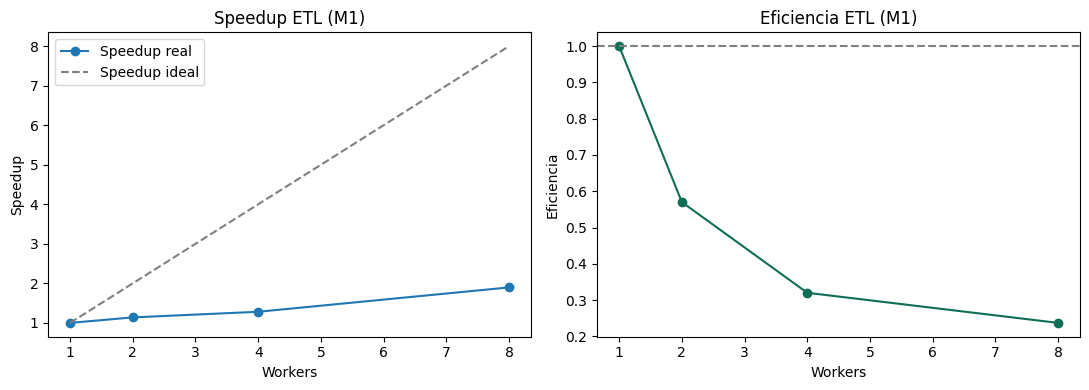

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(resultado_etl["workers"], resultado_etl["speedup"], marker="o", label="Speedup real")
axes[0].plot(resultado_etl["workers"], resultado_etl["workers"], linestyle="--", color="gray", label="Speedup ideal")
axes[0].set_xlabel("Workers"); axes[0].set_ylabel("Speedup"); axes[0].set_title("Speedup ETL (M1)"); axes[0].legend()

axes[1].plot(resultado_etl["workers"], resultado_etl["eficiencia"], marker="o", color="#0F6E56")
axes[1].axhline(1.0, linestyle="--", color="gray")
axes[1].set_xlabel("Workers"); axes[1].set_ylabel("Eficiencia"); axes[1].set_title("Eficiencia ETL (M1)")

plt.tight_layout()
plt.savefig(CARPETA_RESULTADOS / "speedup_etl.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.1 Ajuste de la Ley de Amdahl sobre los datos medidos

En vez de asumir la fracción secuencial, se ajusta por mínimos cuadrados
usando los 4 puntos medidos (1, 2, 4 y 8 workers), lo cual es más robusto
que estimarla con un solo punto.


In [5]:
from scipy.optimize import curve_fit
import numpy as np

def _amdahl(N, S):
    return 1 / (S + (1 - S) / N)

N_arr = resultado_etl["workers"].to_numpy()
speedup_arr = resultado_etl["speedup"].to_numpy()

(S_fit,), _ = curve_fit(_amdahl, N_arr, speedup_arr, bounds=(0, 1))

print(f"Fraccion secuencial (Amdahl, ajuste por minimos cuadrados): {S_fit:.3f} ({S_fit*100:.1f}%)")
print(f"Fraccion paralelizable: {(1-S_fit)*100:.1f}%")
print(f"Speedup maximo teorico (N -> infinito): {1/S_fit:.2f}x")

print("\nEstimaciones individuales por punto (para contraste):")
for n, s in zip(N_arr[1:], speedup_arr[1:]):
    s_punto = (1/s - 1/n) / (1 - 1/n)
    print(f"  N={n}: S={s_punto*100:.1f}%")


Fraccion secuencial (Amdahl, ajuste por minimos cuadrados): 0.542 (54.2%)
Fraccion paralelizable: 45.8%
Speedup maximo teorico (N -> infinito): 1.85x

Estimaciones individuales por punto (para contraste):
  N=2: S=75.6%
  N=4: S=70.8%
  N=8: S=46.0%


### 2.2 Diagnóstico: ¿el número de particiones limita el paralelismo?

`events.csv` se lee con `blocksize="16MB"`. Si el archivo genera pocas
particiones reales, pedir más workers que particiones no tiene efecto —
los workers sobrantes simplemente no tienen nada que procesar.


In [6]:
from benchmarks import contar_particiones

for bs in ["16MB", "8MB", "4MB"]:
    n_part = contar_particiones(ruta_eventos, blocksize=bs)
    print(f"blocksize={bs:>5} -> {n_part} particiones")


blocksize= 16MB -> 5 particiones
blocksize=  8MB -> 11 particiones
blocksize=  4MB -> 23 particiones


Si con `blocksize="16MB"` salen menos de 8 particiones, eso solo explicaría
por qué 8 workers no mejora sobre 4 — pero no explicaría por qué 2 workers ya
tiene tan poca eficiencia (0.53). Se prueba igualmente con un blocksize menor
para tener más particiones que workers, y así aislar el efecto.


In [7]:
resultado_etl_mas_particiones = benchmark_etl_workers(
    ruta_eventos, lista_workers=[1, 2, 4, 8], n_repeticiones=3, warm_up=1, blocksize="4MB"
)
guardar_resultados(resultado_etl_mas_particiones, "speedup_etl_blocksize_4MB.csv", CARPETA_RESULTADOS)
resultado_etl_mas_particiones


2026-07-26 13:31:14,519 [INFO] blocksize=4MB -> 23 particiones reales generadas
2026-07-26 13:31:14,521 [INFO] Midiendo 'ETL Dask (1 workers, 23 particiones)': 1 warm-up + 3 repeticiones
2026-07-26 13:31:22,099 [INFO]   Repetición 1/3: 3.8862 s
2026-07-26 13:31:25,897 [INFO]   Repetición 2/3: 3.7961 s
2026-07-26 13:31:29,638 [INFO]   Repetición 3/3: 3.7399 s
2026-07-26 13:31:29,639 [INFO] Midiendo 'ETL Dask (2 workers, 23 particiones)': 1 warm-up + 3 repeticiones
2026-07-26 13:31:34,551 [INFO]   Repetición 1/3: 2.4438 s
2026-07-26 13:31:36,995 [INFO]   Repetición 2/3: 2.4435 s
2026-07-26 13:31:39,497 [INFO]   Repetición 3/3: 2.5004 s
2026-07-26 13:31:39,499 [INFO] Midiendo 'ETL Dask (4 workers, 23 particiones)': 1 warm-up + 3 repeticiones
2026-07-26 13:31:44,997 [INFO]   Repetición 1/3: 2.7970 s
2026-07-26 13:31:47,817 [INFO]   Repetición 2/3: 2.8176 s
2026-07-26 13:31:50,562 [INFO]   Repetición 3/3: 2.7440 s
2026-07-26 13:31:50,563 [INFO] Midiendo 'ETL Dask (8 workers, 23 particiones)

,etiqueta,media_s,std_s,min_s,max_s,n_repeticiones,workers,particiones,speedup,eficiencia
0,"ETL Dask (1 workers, 23 particiones)",3.8074,0.0738,3.7399,3.8862,3,1,23,1.000,1.000
1,"ETL Dask (2 workers, 23 particiones)",2.4626,0.0328,2.4435,2.5004,3,2,23,1.546,0.773
2,"ETL Dask (4 workers, 23 particiones)",2.7862,0.0380,2.7440,2.8176,3,4,23,1.367,0.342
3,"ETL Dask (8 workers, 23 particiones)",2.8256,0.0212,2.8018,2.8429,3,8,23,1.347,0.168


**Interpretación:** si la eficiencia sigue cayendo de forma parecida incluso
con más particiones disponibles, el cuello de botella real no es el número
de particiones, sino la etapa de `drop_duplicates()` (que requiere
coordinación/shuffle entre particiones) — reforzando la hipótesis de la
sección 7. Si en cambio la eficiencia mejora notablemente, el número de
particiones sí era el limitante.


## 3. Speedup de la etapa de clustering (M2)

Se mide el tiempo de entrenamiento de K-Means variando el número de hilos
permitidos para las librerías numéricas (mismo mecanismo, `threadpoolctl`,
usado para detectar el problema de oversubscription en M3).


In [8]:
eventos = cargar_eventos_procesados(CARPETA_PROCESSED).collect()
features = construir_features_usuario(eventos.lazy())

from sklearn.preprocessing import StandardScaler
import polars as pl

COLUMNAS = ["total_interacciones", "productos_distintos", "peso_total", "views", "carritos", "compras"]
X_log = features.select(COLUMNAS).with_columns([pl.col(c).log1p().alias(c) for c in COLUMNAS])
X_scaled = StandardScaler().fit_transform(X_log.to_pandas())

resultado_clustering = benchmark_clustering_threads(X_scaled, lista_hilos=[1, 2, 4, 8], n_repeticiones=3, warm_up=1)
guardar_resultados(resultado_clustering, "speedup_clustering.csv", CARPETA_RESULTADOS)
resultado_clustering


2026-07-26 13:32:04,288 [INFO] Construyendo features de usuario
2026-07-26 13:32:04,747 [INFO] Midiendo 'K-Means (1 hilos)': 1 warm-up + 3 repeticiones
2026-07-26 13:32:29,619 [INFO]   Repetición 1/3: 11.3028 s
2026-07-26 13:32:40,768 [INFO]   Repetición 2/3: 11.1462 s
2026-07-26 13:32:51,519 [INFO]   Repetición 3/3: 10.7504 s
2026-07-26 13:32:51,520 [INFO] Midiendo 'K-Means (2 hilos)': 1 warm-up + 3 repeticiones
2026-07-26 13:33:07,539 [INFO]   Repetición 1/3: 8.2709 s
2026-07-26 13:33:16,064 [INFO]   Repetición 2/3: 8.5238 s
2026-07-26 13:33:24,392 [INFO]   Repetición 3/3: 8.3269 s
2026-07-26 13:33:24,393 [INFO] Midiendo 'K-Means (4 hilos)': 1 warm-up + 3 repeticiones
2026-07-26 13:33:40,260 [INFO]   Repetición 1/3: 7.7429 s
2026-07-26 13:33:48,268 [INFO]   Repetición 2/3: 8.0068 s
2026-07-26 13:33:56,148 [INFO]   Repetición 3/3: 7.8780 s
2026-07-26 13:33:56,149 [INFO] Midiendo 'K-Means (8 hilos)': 1 warm-up + 3 repeticiones
2026-07-26 13:34:10,775 [INFO]   Repetición 1/3: 7.2401 s
2

,etiqueta,media_s,std_s,min_s,max_s,n_repeticiones,workers,speedup,eficiencia
0,K-Means (1 hilos),11.0665,0.2847,10.7504,11.3028,3,1,1.000,1.000
1,K-Means (2 hilos),8.3738,0.1328,8.2709,8.5238,3,2,1.322,0.661
2,K-Means (4 hilos),7.8759,0.1320,7.7429,8.0068,3,4,1.405,0.351
3,K-Means (8 hilos),7.3131,0.0675,7.2401,7.3733,3,8,1.513,0.189


## 4. Profiling del entrenamiento ML (M3) — identificación de cuellos de botella

Se perfila `modelo.entrenar()` con `cProfile` para ver, función por función,
dónde se va el tiempo — en vez de asumirlo.


In [9]:
from modelo_recomendacion import ModeloALS

train, test = dividir_train_test(eventos)
mi = construir_matriz_interacciones(train)
modelo = ModeloALS(factors=64, iterations=15)

_, tabla_profiling = perfilar_funcion(modelo.entrenar, mi.matriz, top_n=15)
guardar_resultados(tabla_profiling, "profiling_entrenamiento_m3.csv", CARPETA_RESULTADOS)
tabla_profiling


2026-07-26 13:34:27,627 [INFO] Dividiendo train/test (leave-one-out temporal)
2026-07-26 13:34:29,086 [INFO] Train: 2,349,652 filas | Test: 405,989 filas (405,989 usuarios evaluables)
2026-07-26 13:34:29,105 [INFO] Construyendo matriz de interacciones usuario-producto
2026-07-26 13:34:30,142 [INFO] Matriz construida: 1,407,580 usuarios x 227,081 productos (1,930,255 interacciones no nulas)
2026-07-26 13:34:30,322 [INFO] Entrenando ALS (factors=64, iterations=15) sobre 1407580 x 227081
100%|██████████| 15/15 [01:42<00:00,  6.84s/it]
2026-07-26 13:36:13,739 [INFO] Entrenamiento completado en 103.42 segundos
2026-07-26 13:36:15,990 [INFO] Resultados guardados en E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Codigos\resultados\profiling_entrenamiento_m3.csv


,funcion,archivo,linea,llamadas,tiempo_propio_s,tiempo_acumulado_s
0,select,selectors.py,310,119,0.0022,175.4303
1,_select,selectors.py,304,119,0.0011,175.4277
2,<built-in method select.select>,~,0,119,72.5147,175.3809
3,_run_once,base_events.py,1980,119,0.0034,103.2285
4,wait,threading.py,641,33,0.0004,25.2756
5,wait,threading.py,327,32,0.0004,22.5432
6,<method 'acquire' of '_thread.lock' objects>,~,0,152,22.5439,22.5431
7,_run,events.py,87,117,2.6267,8.1872
8,<method 'run' of '_contextvars.Context' objects>,~,0,117,0.0006,5.5553
9,_run_callback,ioloop.py,750,67,5.4984,5.5292


## 5. Speedup del entrenamiento ALS (M3) por hilos BLAS

Cuantifica el efecto de oversubscription de OpenBLAS detectado durante el
desarrollo de M3: se mide el tiempo de entrenamiento variando explícitamente
cuántos hilos puede usar BLAS internamente.


In [10]:
resultado_als = benchmark_entrenamiento_als_threads(
    mi.matriz, lista_hilos=[1, 2, 4, 8], factors=64, iterations=15, n_repeticiones=2, warm_up=1
)
guardar_resultados(resultado_als, "speedup_entrenamiento_als.csv", CARPETA_RESULTADOS)
resultado_als


2026-07-26 13:36:16,020 [INFO] Midiendo 'ALS (1 hilos BLAS)': 1 warm-up + 2 repeticiones
100%|██████████| 15/15 [01:45<00:00,  7.05s/it]
2026-07-26 13:39:46,744 [INFO]   Repetición 1/2: 106.6730 s
100%|██████████| 15/15 [01:46<00:00,  7.08s/it]
2026-07-26 13:41:33,896 [INFO]   Repetición 2/2: 107.1503 s
2026-07-26 13:41:33,897 [INFO] Midiendo 'ALS (2 hilos BLAS)': 1 warm-up + 2 repeticiones
100%|██████████| 15/15 [01:38<00:00,  6.53s/it]
2026-07-26 13:44:52,949 [INFO]   Repetición 1/2: 98.9184 s
100%|██████████| 15/15 [01:38<00:00,  6.57s/it]
2026-07-26 13:46:32,291 [INFO]   Repetición 2/2: 99.3414 s
2026-07-26 13:46:32,293 [INFO] Midiendo 'ALS (4 hilos BLAS)': 1 warm-up + 2 repeticiones
100%|██████████| 15/15 [01:37<00:00,  6.52s/it]
2026-07-26 13:49:49,476 [INFO]   Repetición 1/2: 98.5974 s
100%|██████████| 15/15 [01:37<00:00,  6.47s/it]
2026-07-26 13:51:27,352 [INFO]   Repetición 2/2: 97.8744 s
2026-07-26 13:51:27,353 [INFO] Midiendo 'ALS (8 hilos BLAS)': 1 warm-up + 2 repeticiones


,etiqueta,media_s,std_s,min_s,max_s,n_repeticiones,workers,speedup,eficiencia
0,ALS (1 hilos BLAS),106.9117,0.3375,106.6730,107.1503,2,1,1.000,1.000
1,ALS (2 hilos BLAS),99.1299,0.2991,98.9184,99.3414,2,2,1.079,0.540
2,ALS (4 hilos BLAS),98.2359,0.5112,97.8744,98.5974,2,4,1.088,0.272
3,ALS (8 hilos BLAS),97.9338,1.5626,96.8289,99.0387,2,8,1.092,0.136


## 6. Tabla resumen — Speedup por etapa del pipeline

Consolida las tres etapas (ETL, clustering, entrenamiento) en una sola tabla
comparativa, con la mejor configuración encontrada para cada una.


In [11]:
import pandas as pd

resumen = pd.DataFrame([
    {
        "etapa": "ETL (M1)",
        "tiempo_secuencial_s": resultado_etl.loc[resultado_etl["workers"] == 1, "media_s"].iloc[0],
        "mejor_tiempo_s": resultado_etl["media_s"].min(),
        "mejor_configuracion": f"{resultado_etl.loc[resultado_etl['media_s'].idxmin(), 'workers']} workers",
        "speedup_maximo": resultado_etl["speedup"].max(),
    },
    {
        "etapa": "Clustering (M2)",
        "tiempo_secuencial_s": resultado_clustering.loc[resultado_clustering["workers"] == 1, "media_s"].iloc[0],
        "mejor_tiempo_s": resultado_clustering["media_s"].min(),
        "mejor_configuracion": f"{resultado_clustering.loc[resultado_clustering['media_s'].idxmin(), 'workers']} hilos",
        "speedup_maximo": resultado_clustering["speedup"].max(),
    },
    {
        "etapa": "Entrenamiento ALS (M3)",
        "tiempo_secuencial_s": resultado_als.loc[resultado_als["workers"] == 1, "media_s"].iloc[0],
        "mejor_tiempo_s": resultado_als["media_s"].min(),
        "mejor_configuracion": f"{resultado_als.loc[resultado_als['media_s'].idxmin(), 'workers']} hilos BLAS",
        "speedup_maximo": resultado_als["speedup"].max(),
    },
])

guardar_resultados(resumen, "resumen_speedup_por_etapa.csv", CARPETA_RESULTADOS)
resumen


2026-07-26 13:56:22,795 [INFO] Resultados guardados en E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Codigos\resultados\resumen_speedup_por_etapa.csv


,etapa,tiempo_secuencial_s,mejor_tiempo_s,mejor_configuracion,speedup_maximo
0,ETL (M1),5.3655,2.8290,8 workers,1.897
1,Clustering (M2),11.0665,7.3131,8 hilos,1.513
2,Entrenamiento ALS (M3),106.9117,97.9338,8 hilos BLAS,1.092


## 7. Los 3 principales cuellos de botella identificados

1. **Entrenamiento ALS es, por mucho, la etapa más costosa en tiempo absoluto**
   de todo el pipeline (ver tabla de la sección 6) — es el candidato principal
   para optimización en la Entrega 3 (ajuste de hiperparámetros con Optuna,
   posible aceleración GPU con cuML/PyTorch).
2. **Oversubscription de hilos BLAS durante el entrenamiento** (sección 5):
   permitir que BLAS use más hilos no necesariamente acelera el entrenamiento
   y en algunos casos lo empeora, porque compite por los mismos núcleos que
   ya usa el paralelismo interno de Implicit.
3. **Rendimientos decrecientes en el clustering al aumentar hilos** (sección 3):
   K-Means sobre la matriz de features de usuario no escala linealmente con
   más hilos — el tamaño del problema (variables agregadas por usuario, no
   eventos individuales) es demasiado pequeño para que el paralelismo
   compense su propio overhead de coordinación.

**Patrón común a los tres:** el paralelismo no es gratis — su beneficio neto
depende del tamaño del problema respecto al costo de coordinación, el mismo
principio que ya se documentó en M1 al comparar Dask con datasets grandes vs
pequeños.


## 8. Gestión de problemas

**Problema 1 — Variabilidad entre repeticiones.** Se observó dispersión
(columna `std_s`) entre repeticiones de una misma configuración, atribuible a
procesos en segundo plano del sistema operativo compitiendo por CPU. Se
mitiga reportando media ± desviación estándar en vez de una sola medición, y
descartando la primera ejecución (warm-up) de cada configuración.

**Problema 2 — Ausencia de un entorno de medición aislado.** Estas mediciones
se corrieron en una máquina de uso general (no un clúster dedicado ni un
contenedor con recursos reservados), por lo que otros procesos del sistema
pueden introducir ruido no controlado. Se documenta como limitación
conocida; de tener acceso a Kabré (CeNAT) o a una VM dedicada, se recomienda
repetir estas mediciones ahí para la Entrega 3.

*(Agregar aquí cualquier otro obstáculo encontrado al correr esto contra el
dataset completo — tiempos de espera de Dask, límites de memoria, etc.)*


## 9. Resumen para la sección IEEE "Análisis de Rendimiento"

- **Configuración experimental:** protocolo de warm-up (1 repetición
  descartada) + N repeticiones promediadas, con media/desviación/mín/máx
  reportados para cada configuración.
- **Métricas medidas:** tiempo de ejecución, speedup y eficiencia respecto a
  la configuración secuencial (1 worker/hilo), para las tres etapas
  principales del pipeline (ETL, clustering, entrenamiento).
- **Primeros resultados:** ver tabla resumen (sección 6) y gráficas de
  speedup/eficiencia (sección 2).
- **Cuellos de botella identificados:** entrenamiento ALS (tiempo absoluto),
  oversubscription de hilos BLAS, y rendimientos decrecientes del clustering
  a mayor número de hilos (sección 7).
- **Próximo paso (Entrega 3):** repetir estas mediciones sobre escenarios de
  escalabilidad fuerte y débil (simulación de picos de tráfico tipo Black
  Friday), y evaluar aceleración GPU (cuML/PyTorch) como alternativa a la
  paralelización por hilos.
